# 01 - EDA | B3 Quant Analytics

Notebook de apresentação para entrevista: visão de negócio, diagnóstico de risco/retorno e insights acionáveis para carteira de ações da B3.

**Perguntas que este notebook responde**
1. Quais ativos entregam melhor relação risco-retorno?
2. Como a volatilidade evoluiu no tempo?
3. Quais ativos se movem juntos (correlação)?

In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

sns.set_theme(style="whitegrid", context="talk")

PROJECT_ROOT = Path("..").resolve()
if str(PROJECT_ROOT / "src") not in sys.path:
    sys.path.append(str(PROJECT_ROOT / "src"))

DATA_PATH = PROJECT_ROOT / "data" / "processed" / "features.csv"

In [2]:
if not DATA_PATH.exists():
    raise FileNotFoundError(
        "Arquivo data/processed/features.csv não encontrado. Execute antes: python src/main.py run"
    )

df = pd.read_csv(DATA_PATH, parse_dates=["date"])
df = df.sort_values(["ticker", "date"]).reset_index(drop=True)
df.head()

,date,adj_close,close,high,low,open,volume,ticker,daily_return,log_return,volatility_rolling,var_historical_rolling,sharpe_ratio,adf_pvalue
0,2020-01-02,19.295866,28.181818,28.181818,27.197596,27.445530,25031584.0,BBDC4.SA,NaN,NaN,NaN,NaN,-0.362413,9.177839e-18
1,2020-01-03,19.305624,28.181818,28.549961,27.708488,27.723516,39999078.0,BBDC4.SA,0.000000,0.000000,NaN,NaN,-0.362413,9.177839e-18
2,2020-01-06,18.960789,27.678436,28.009014,27.377910,27.948910,33675497.0,BBDC4.SA,-0.017862,-0.018023,NaN,NaN,-0.362413,9.177839e-18
3,2020-01-07,18.631401,27.197596,27.768595,27.047333,27.610819,19775066.0,BBDC4.SA,-0.017372,-0.017525,NaN,NaN,-0.362413,9.177839e-18
4,2020-01-08,18.343176,26.776860,27.438017,26.641623,27.325320,28306110.0,BBDC4.SA,-0.015470,-0.015591,NaN,NaN,-0.362413,9.177839e-18


In [3]:
summary = df.groupby("ticker", as_index=False).agg(
    retorno_medio_diario=("daily_return", "mean"),
    volatilidade_diaria=("daily_return", "std"),
    sharpe=("sharpe_ratio", "first"),
    var_95=("var_historical_rolling", "median"),
)
summary["retorno_anualizado"] = summary["retorno_medio_diario"] * 252
summary["vol_anualizada"] = summary["volatilidade_diaria"] * (252**0.5)
summary = summary.sort_values("sharpe", ascending=False)
summary.round(4)

,ticker,retorno_medio_diario,volatilidade_diaria,sharpe,var_95,retorno_anualizado,vol_anualizada
3,VALE3.SA,0.0004,0.0227,-0.0288,-0.0243,0.1119,0.3605
2,PETR4.SA,0.0004,0.0272,-0.0584,-0.0275,0.0971,0.4317
1,ITUB4.SA,0.0003,0.0193,-0.1581,-0.0201,0.0737,0.3070
0,BBDC4.SA,-0.0000,0.0227,-0.3624,-0.0228,-0.0085,0.3608


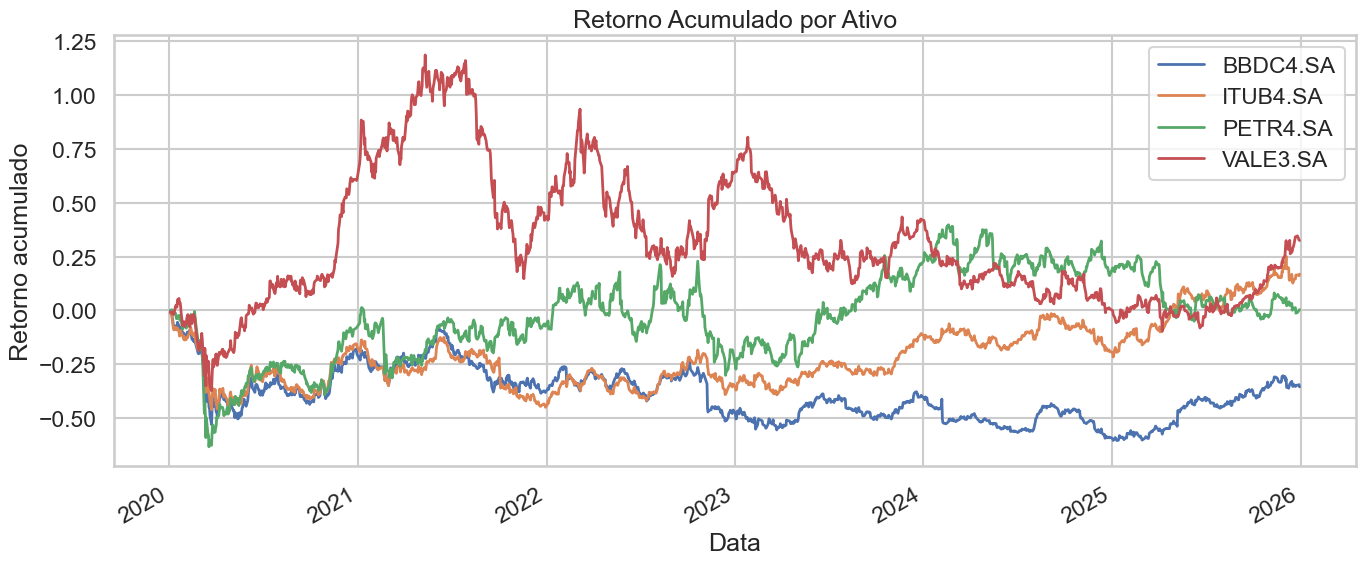

In [4]:
returns_pivot = df.pivot_table(index="date", columns="ticker", values="daily_return")
cum_returns = (1 + returns_pivot.fillna(0)).cumprod() - 1

ax = cum_returns.plot(figsize=(14, 6), linewidth=2)
ax.set_title("Retorno Acumulado por Ativo")
ax.set_ylabel("Retorno acumulado")
ax.set_xlabel("Data")
plt.legend(loc="best")
plt.tight_layout()
plt.show()

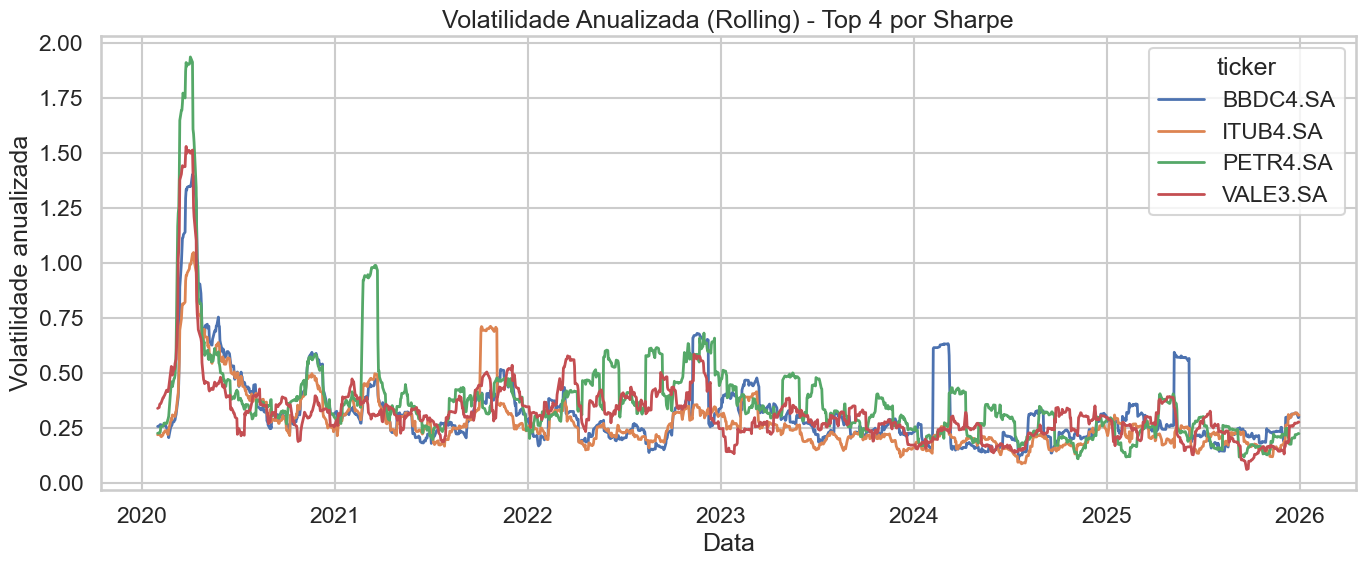

In [5]:
top_tickers = summary["ticker"].head(4).tolist()
plot_df = df[df["ticker"].isin(top_tickers)].copy()

plt.figure(figsize=(14, 6))
sns.lineplot(data=plot_df, x="date", y="volatility_rolling", hue="ticker", linewidth=2)
plt.title("Volatilidade Anualizada (Rolling) - Top 4 por Sharpe")
plt.ylabel("Volatilidade anualizada")
plt.xlabel("Data")
plt.tight_layout()
plt.show()

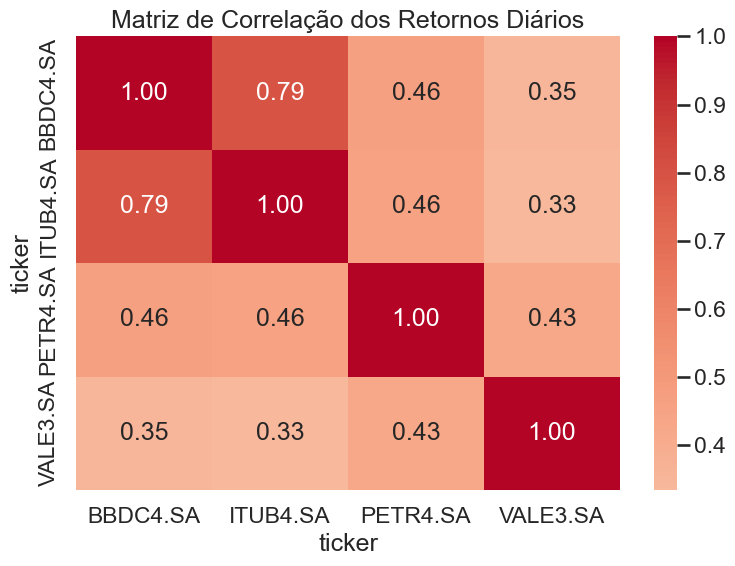

In [6]:
corr = returns_pivot.corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Matriz de Correlação dos Retornos Diários")
plt.tight_layout()
plt.show()

## Tópicos de discussão
- Mostro primeiro o ranking por **Sharpe** para justificar risco-retorno.
- Em seguida, evidencio que retorno acumulado sem risco não é suficiente: a curva de volatilidade explica períodos de stress.
- Finalizo com correlação para discutir **diversificação de carteira** e redução de risco total.